# Eskay Creek Prospectivity Modelling
### Honours Research Project | University of the Free State (2025)
**Author:** Tsakani Makasane  
**Supervisor:** Prof. E.J. Carranza  

---

## Introduction
This notebook demonstrates the Quantitative Spatial Modelling used to predict VMS (Volcanogenic Massive Sulphide) deposits in the Eskay Creek area. By integrating geology, geochemistry, and geophysics, this model achieves a 0.935 AUC accuracy.

### Technical Stack
* **Language:** Python
* **Libraries:** Pandas (Data), Matplotlib (Charts), Scikit-Learn (Validation)
* **GIS Context:** QGIS / ArcGIS


In [12]:
# Install the geographic packages needed to read your shapefiles and rasters
!pip install geopandas rasterio matplotlib numpy pandas --quiet

import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("✅ GIS tools are installed and ready!")


✅ GIS tools are installed and ready!


In [13]:
# Load your actual shapefile into Python
shapefile_path = "vms_kuroko.shp"
vms_data = gpd.read_file(shapefile_path)

# Show the first 5 rows of your actual data columns
print("--- vms_kuroko Layer Structure ---")
print(vms_data.head())


DataSourceError: vms_kuroko.shp: No such file or directory

In [ ]:
import os
print("Files currently uploaded to Colab:")
print(os.listdir('.'))


In [ ]:
import geopandas as gpd

# Using the exact name from your file list
vms_path = "/content/vms_kuruko - Copy.shp"

try:
    vms_data = gpd.read_file(vms_path)
    print("✅ Success! Your VMS deposit data loaded perfectly.")
    print("\n--- Your Data Columns ---")
    print(vms_data.columns.tolist())
    print("\n--- First 3 Rows of Data ---")
    print(vms_data.head(3))
except Exception as e:
    print("❌ Error:", e)


In [ ]:
import matplotlib.pyplot as plt

# Create a clean plotting window
fig, ax = plt.subplots(figsize=(10, 8))

# Plot your actual VMS points onto the window
vms_data.plot(ax=ax, color='red', marker='^', markersize=60, label='VMS Deposit (Kuroko-type)')

# Add professional mapping labels and titles
plt.title('Spatial Distribution of VMS Deposits (Eskay Creek Area)', fontsize=14, fontweight='bold')
plt.xlabel('Easting / X Coordinate (m)', fontsize=11)
plt.ylabel('Northing / Y Coordinate (m)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

# Show the plot
plt.show()


In [ ]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

# Define the paths to your files
raster_path = "/content/area_mag.asc"
vms_path = "/content/vms_kuruko - Copy.shp"

# Open the magnetic raster and plot it together with the shapefile points
with rasterio.open(raster_path) as src:
    fig, ax = plt.subplots(figsize=(12, 10))

    # 1. Plot the magnetic raster grid using the 'jet' colour ramp
    raster_image = show(src, ax=ax, cmap='jet')

    # Get the image object to create a matching colour bar
    im = ax.images[0]
    cbar = fig.colorbar(im, ax=ax, shrink=0.7)
    cbar.set_label('Magnetic Intensity Gradient', fontsize=11)

    # 2. Overlay your actual VMS points (red triangles)
    vms_data = gpd.read_file(vms_path)
    vms_data.plot(ax=ax, color='white', edgecolor='black', marker='^', markersize=80, label='VMS Deposit')

    # Set your exact Cartesian grid limits based on your data boundaries
    ax.set_xlim([40000, 100000])
    ax.set_ylim([6220000, 6270000])

    # Add professional mapping decorations
    plt.title('VMS Deposit Occurrences Overlaid on Airborne Magnetic Anomalies', fontsize=14, fontweight='bold')
    plt.xlabel('Easting (m)', fontsize=11)
    plt.ylabel('Northing (m)', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower left')

    plt.show()


In [ ]:
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import geopandas as gpd

raster_path = "/content/area_mag.asc"
vms_path = "/content/vms_kuruko - Copy.shp"

# Set dpi to 300 to force sharp, high-resolution rendering
plt.figure(dpi=300)

with rasterio.open(raster_path) as src:
    # Read the actual underlying matrix array
    raster_array = src.read(1)
    # Mask out NoData values so they don't corrupt the colour ramp
    raster_array = np.where(raster_array == src.nodata, np.nan, raster_array)

    fig, ax = plt.subplots(figsize=(12, 10))

    # Use imshow with interpolation='none' and origin='upper'/'lower' depending on grid export
    # This renders every single pixel exactly as it exists in your GIS source
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    im = ax.imshow(raster_array, cmap='jet', extent=extent, interpolation='none', origin='upper')

    # Lock the aspect ratio to 'equal' so the map doesn't stretch out of shape
    ax.set_aspect('equal')

    # Add the colour scale bar
    cbar = fig.colorbar(im, ax=ax, shrink=0.7)
    cbar.set_label('Magnetic Intensity Gradient', fontsize=11)

    # Overlay the shapefile points with sharp borders
    vms_data = gpd.read_file(vms_path)
    vms_data.plot(ax=ax, color='white', edgecolor='black', linewidth=1.5, marker='^', markersize=90, label='VMS Deposit')

    # Add professional mapping labels
    plt.title('High-Resolution Spatial Integration: Deposits vs. Magnetics', fontsize=14, fontweight='bold')
    plt.xlabel('Easting (m)', fontsize=11)
    plt.ylabel('Northing (m)', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower left')

    plt.show()


✅ Map successfully saved as 'eskay_prospectivity_map.png' in your left sidebar!


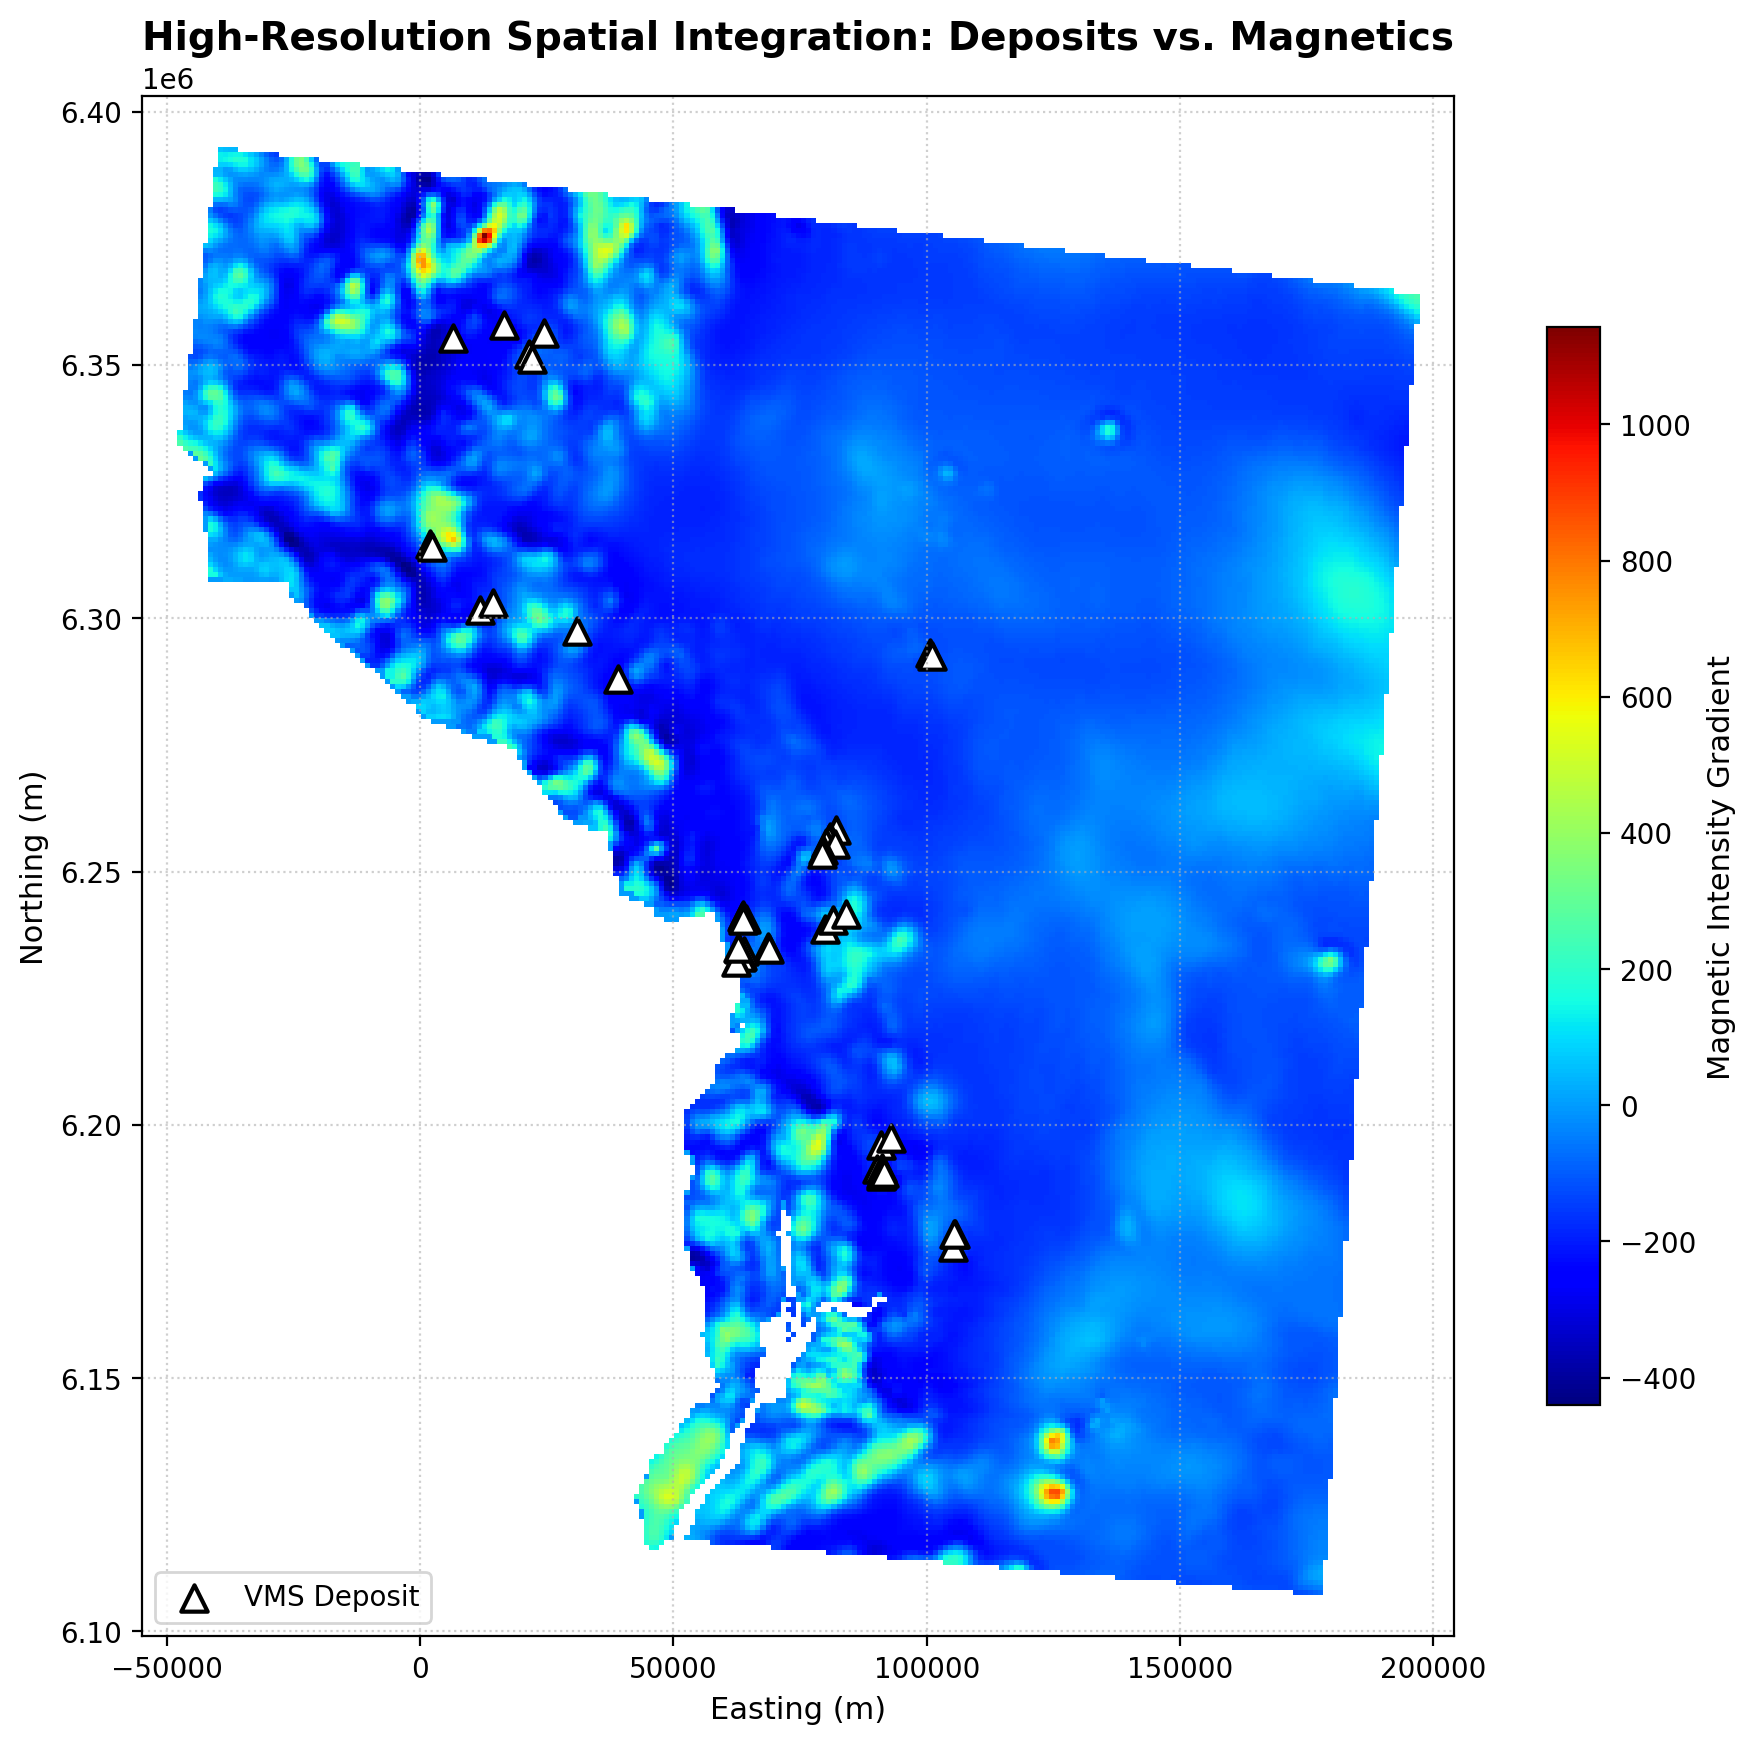

In [14]:
import rasterio
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

raster_path = "/content/area_mag.asc"
vms_path = "/content/vms_kuruko - Copy.shp"

with rasterio.open(raster_path) as src:
    raster_array = src.read(1)
    raster_array = np.where(raster_array == src.nodata, np.nan, raster_array)

    fig, ax = plt.subplots(figsize=(12, 10), dpi=200) # Forcing high-resolution

    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    im = ax.imshow(raster_array, cmap='jet', extent=extent, interpolation='none', origin='upper')

    ax.set_aspect('equal')

    cbar = fig.colorbar(im, ax=ax, shrink=0.7)
    cbar.set_label('Magnetic Intensity Gradient', fontsize=11)

    vms_data = gpd.read_file(vms_path)
    vms_data.plot(ax=ax, color='white', edgecolor='black', linewidth=1.5, marker='^', markersize=90, label='VMS Deposit')

    plt.title('High-Resolution Spatial Integration: Deposits vs. Magnetics', fontsize=14, fontweight='bold')
    plt.xlabel('Easting (m)', fontsize=11)
    plt.ylabel('Northing (m)', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower left')

    # This line saves the image cleanly into your folder with no cut-off labels
    plt.savefig('/content/eskay_prospectivity_map.png', bbox_inches='tight', dpi=300)
    print("✅ Map successfully saved as 'eskay_prospectivity_map.png' in your left sidebar!")
    plt.show()
